---
title: Model Selection
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

In this work, we are interested in learning associations between AR landfalling characteristics and their downstream impacts on the Antarctic ice sheet, by way of surface temperature anomalies and cumulative snowfall, both in an average sense as well as an extreme sense. We accomplish this task by fitting models that predict our outcome of interest, whether average or extreme, as a function of our selected covariates, and examine the learned patterns. To model average outcomes, we use `xgboost`, a modern machine learning tree ensemble technique, and to model the extreme outcomes, we use `gbex`, an algorithm which blends tree ensemble boosting with statistical extreme value theory. 

Each of these models has several tuneable hyperparameters, each combination of which leads to a different model to train on our data. In this notebook, for each of `xgboost` and `gbex` on each outcome of interest, we walk through our hyperparameter selection process. In summary, we employ a grid-search approach, examining performance of each model on held-out sets of data via 5-fold cross validation for each combination of hyperparameters in a grid. We successively refine our grid search region over multiple rounds until we are reasonably satisfied with the resulting model.

## Average Outcomes: xgboost

We first detail our hyperparameter selection procedure on the `xgboost` models. In `xgboost`, there are several hyperparameters, including:

### Cumulative Snowfall

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import os
import json
from IPython.display import display, JSON
import matplotlib.pyplot as plt
import math

Matplotlib is building the font cache; this may take a moment.


In [2]:
def plot_histograms(df, hyperparameter, bins):

    params = np.sort(df[hyperparameter].unique())
    
    n_params = len(params)
    n_cols = 2 if n_params > 1 else 1
    n_rows = math.ceil(n_params / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3), sharex=True)
    axes = axes.flatten()

    for i, param in enumerate(params):
        ax = axes[i]
        param_R2 = df[df[hyperparameter] == param]

        sns.histplot(data=param_R2, x='val_r2_mean', ax=ax, bins=bins)
        ax.set_title(f'{param}')
        ax.set_xlabel('R2')
        ax.set_ylabel("Count")
    fig.tight_layout()
    plt.show()

## Non-Extreme

### Round 1: Snow

The hyperparameters used in the grid for round 1 are displayed in the JSON below.

In [4]:
with open('../auxiliary_files/hyperparam_dictionaries/xgboost/snow_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)
display(JSON(json_data))

<IPython.core.display.JSON object>

In [10]:
round1_snow = pd.read_csv('../outputs/model_fitting/xgboost/cross_validation/snow_xgb_round1.csv')

Before beginning our search, let's first see what our best-performing model was for this round.

In [13]:
round1_snow.iloc[round1_snow.val_r2_mean.idxmax()]

Unnamed: 0                 1566.000000
gamma                         0.000000
max_depth                     3.000000
reg_lambda                    1.000000
min_child_weight              0.000000
subsample_frac                0.700000
eta                           0.010000
num_boost                   638.000000
shrinkage_factor              1.011189
val_rmse_mean                 0.226428
val_r2_mean                   0.876228
test-r2-mean-ols-shrunk       0.822256
test-r2-mean-ols              0.822217
Name: 1566, dtype: float64

Starting with `min_child_weight`. Seems like [0,10] is reasonable to search next.

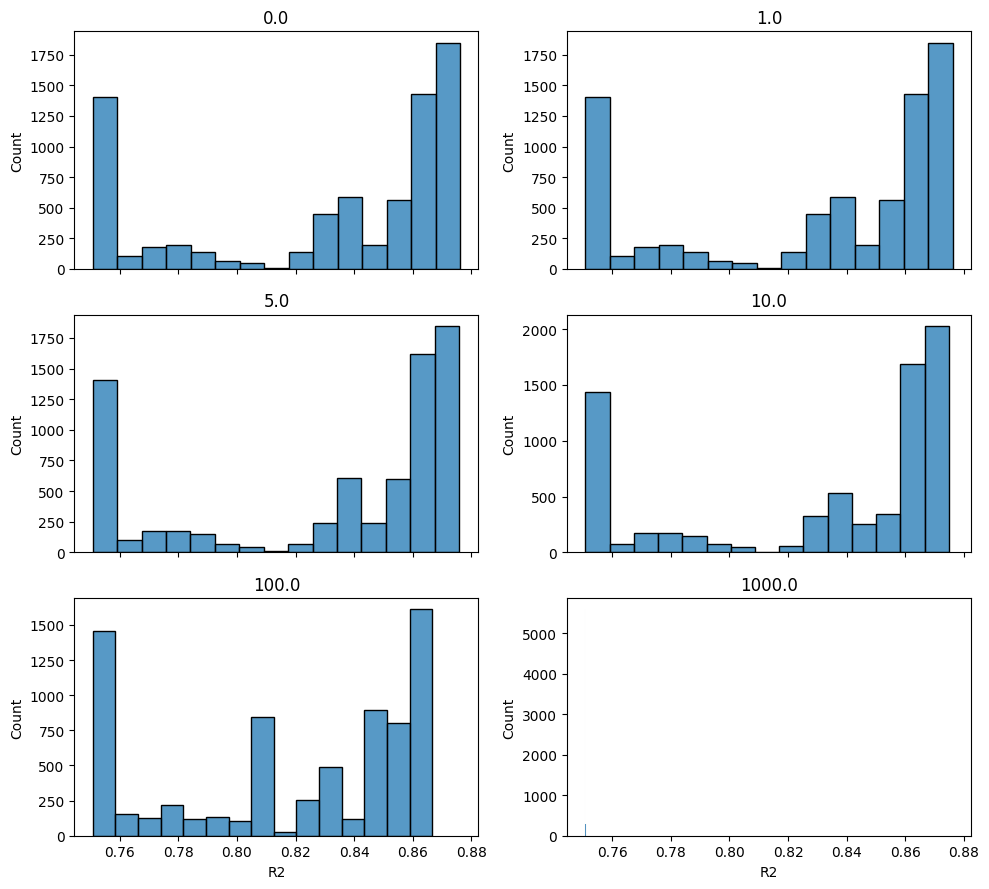

In [11]:
plot_histograms(round1_snow, 'min_child_weight', 15)

In [12]:
round1_snow.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0       0.876228
1.0       0.876228
5.0       0.875926
10.0      0.874998
100.0     0.866708
1000.0    0.751056
Name: val_r2_mean, dtype: float64

A reasonable choice $[0,10]$

`gamma`: [0,1]

In [15]:
round1_snow.groupby('gamma')['val_r2_mean'].max()

gamma
0.0000      0.876228
0.0001      0.876228
0.0010      0.875992
0.0100      0.875956
1.0000      0.872781
10.0000     0.809736
100.0000    0.751694
Name: val_r2_mean, dtype: float64

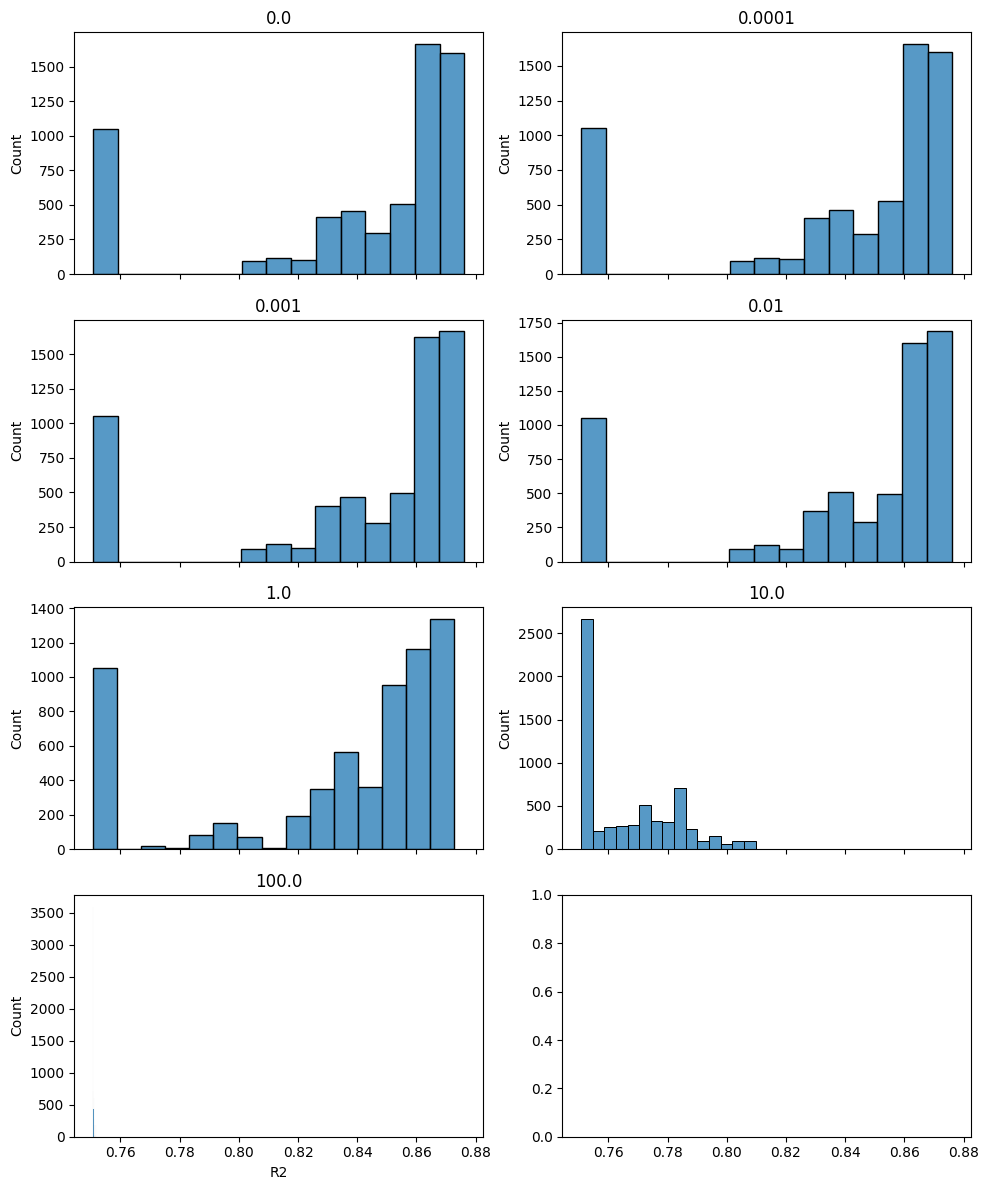

In [16]:
plot_histograms(round1_snow, 'gamma', 15)

`max_depth`: [2,7]

In [17]:
round1_snow.groupby('max_depth')['val_r2_mean'].max()

max_depth
1.0     0.842298
3.0     0.876228
5.0     0.874797
7.0     0.873213
10.0    0.872105
15.0    0.872113
Name: val_r2_mean, dtype: float64

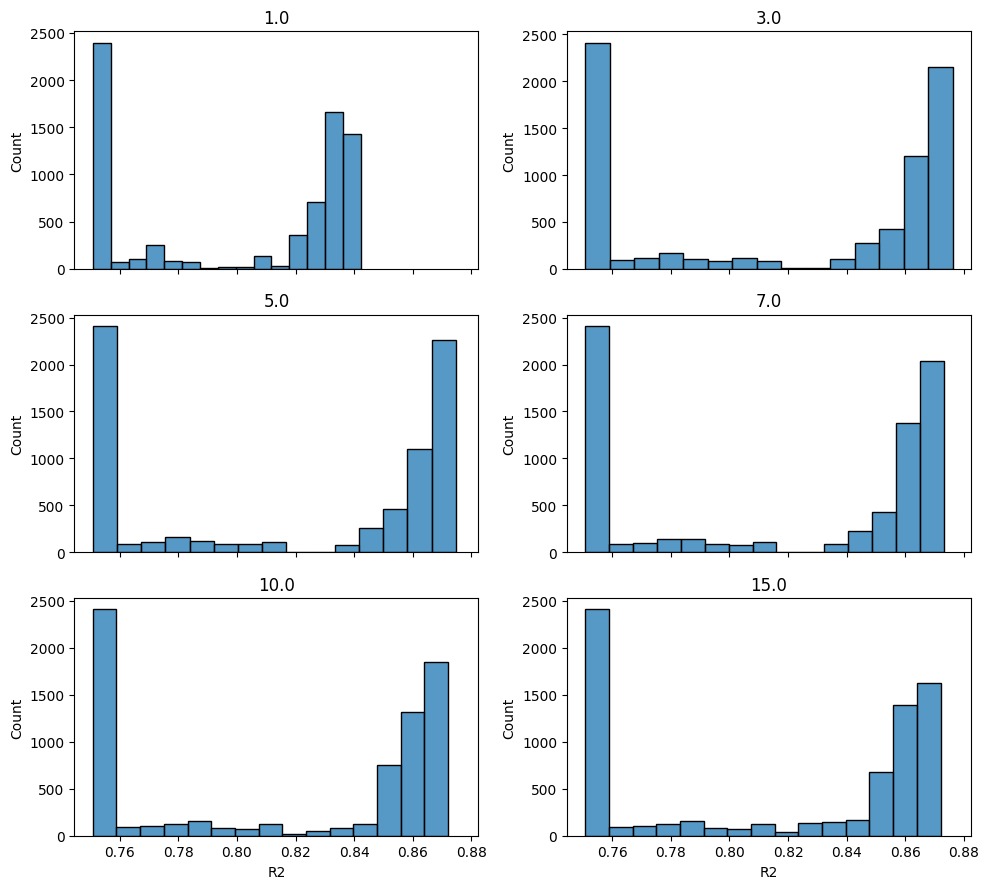

In [18]:
plot_histograms(round1_snow, 'max_depth', 15)

`reg_lambda`: [0,10], maybe numbers that are larger?

In [19]:
round1_snow.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000      0.875926
0.001      0.875851
0.010      0.875803
0.100      0.875532
1.000      0.876228
10.000     0.874709
100.000    0.873966
Name: val_r2_mean, dtype: float64

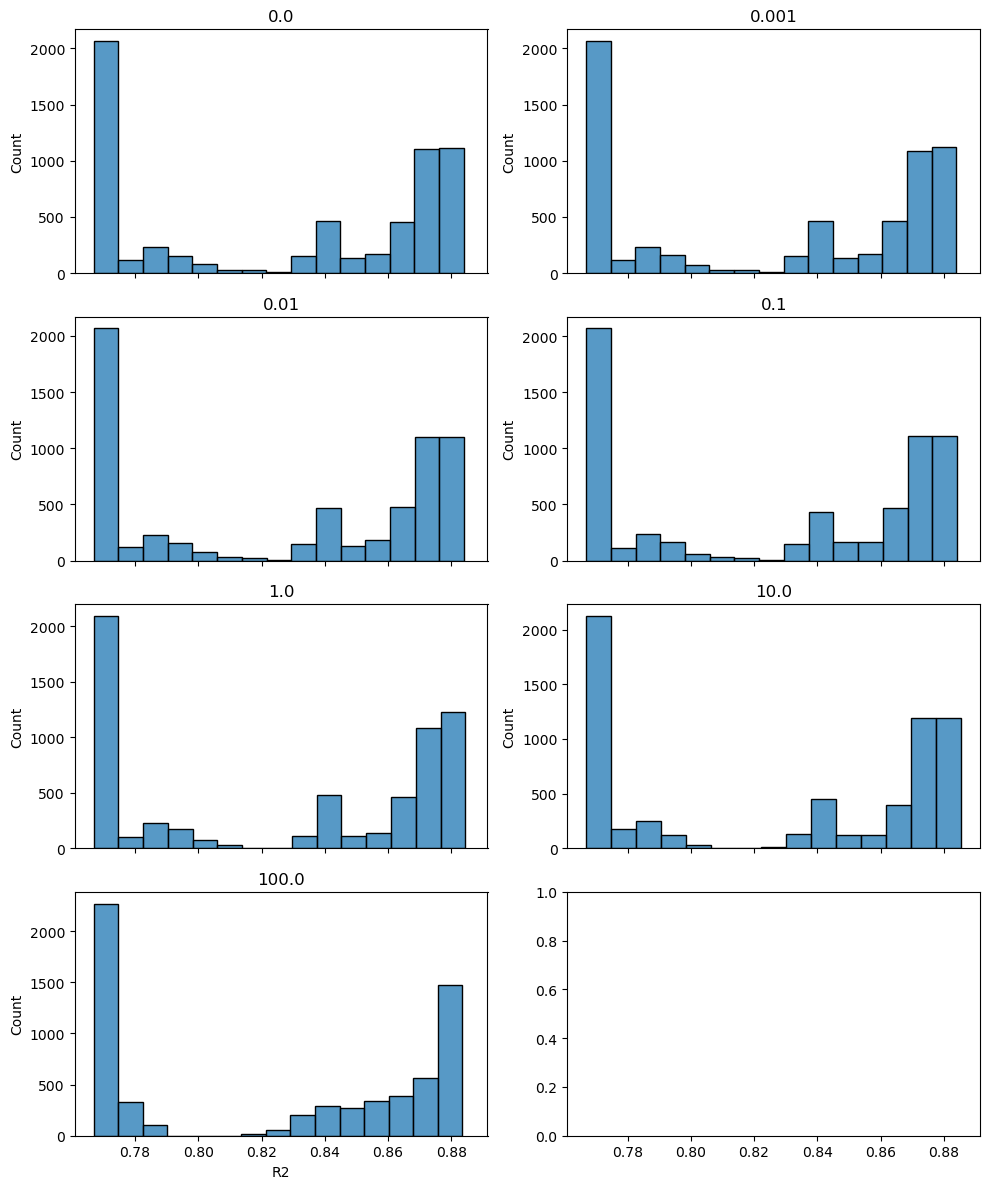

In [116]:
plot_histograms(round1_snow, 'reg_lambda', 15)

Values seem very similar for all $\lambda$. I'm going to do a more evenly spaced grid between $[0, 100]$, instead of logarithmically spaced as before. It seems like with low lambdas, the values are quite similar, then they go up a bit at $\lambda = 10$, and then they start to go down with higher $\lambda$. So, It'll be good to get more values in the $10$s.

`subsample_frac`: [0.5, 1]

In [20]:
round1_snow.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.1    0.872937
0.3    0.874709
0.5    0.875909
0.7    0.876228
1.0    0.875269
Name: val_r2_mean, dtype: float64

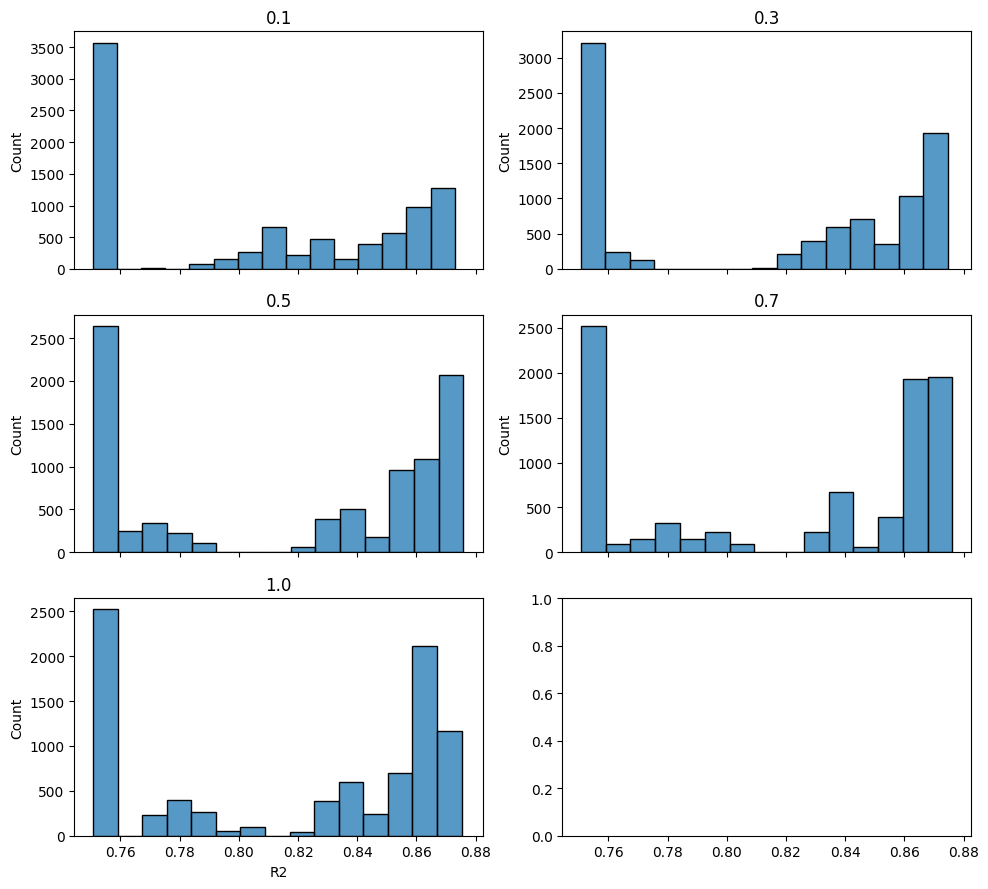

In [21]:
plot_histograms(round1_snow, 'subsample_frac', 15)

In [123]:
round1_snow.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.883398
0.010    0.884058
0.050    0.884830
0.100    0.885501
0.300    0.883525
Name: val_r2_mean, dtype: float64

It seems like the very small learning rates are slightly worse, along with the larger ones. Let's Look between $[0.05, 0.3]$.

Round 1 Snow Conclusions

+ `eta`: $[0.05, 0.3]$
+ `subsample_frac`: $[0.5, 1]$
+ `reg_lambda`: $[0,10]$ (but more evenly spaced than before)
+ `max_depth`: $[2, 7]$
+ `gamma`: $[0, 0.05]$
+ `min_child_weight`: $[0,5]$

### Round 2: Snow

### Round 1: Temp

In [126]:
with open('rounds/temp_round1.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [22]:
round1_temp = pd.read_csv('../outputs/model_fitting/xgboost/cross_validation/temp_xgb_round1.csv', index_col=False)

In [23]:
round1_temp.iloc[round1_temp.val_r2_mean.idxmax()]

Unnamed: 0                 39556.000000
gamma                        100.000000
max_depth                      5.000000
reg_lambda                     0.010000
min_child_weight               5.000000
subsample_frac                 0.300000
eta                            0.010000
num_boost                    335.000000
shrinkage_factor               1.049601
val_rmse_mean                  5.031561
val_r2_mean                    0.595106
test-r2-mean-ols-shrunk        0.520691
test-r2-mean-ols               0.520684
Name: 39556, dtype: float64

In [24]:
round1_temp.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0       5.935999e-01
1.0       5.935999e-01
5.0       5.951064e-01
10.0      5.939638e-01
100.0     5.833798e-01
1000.0    6.661338e-17
Name: val_r2_mean, dtype: float64

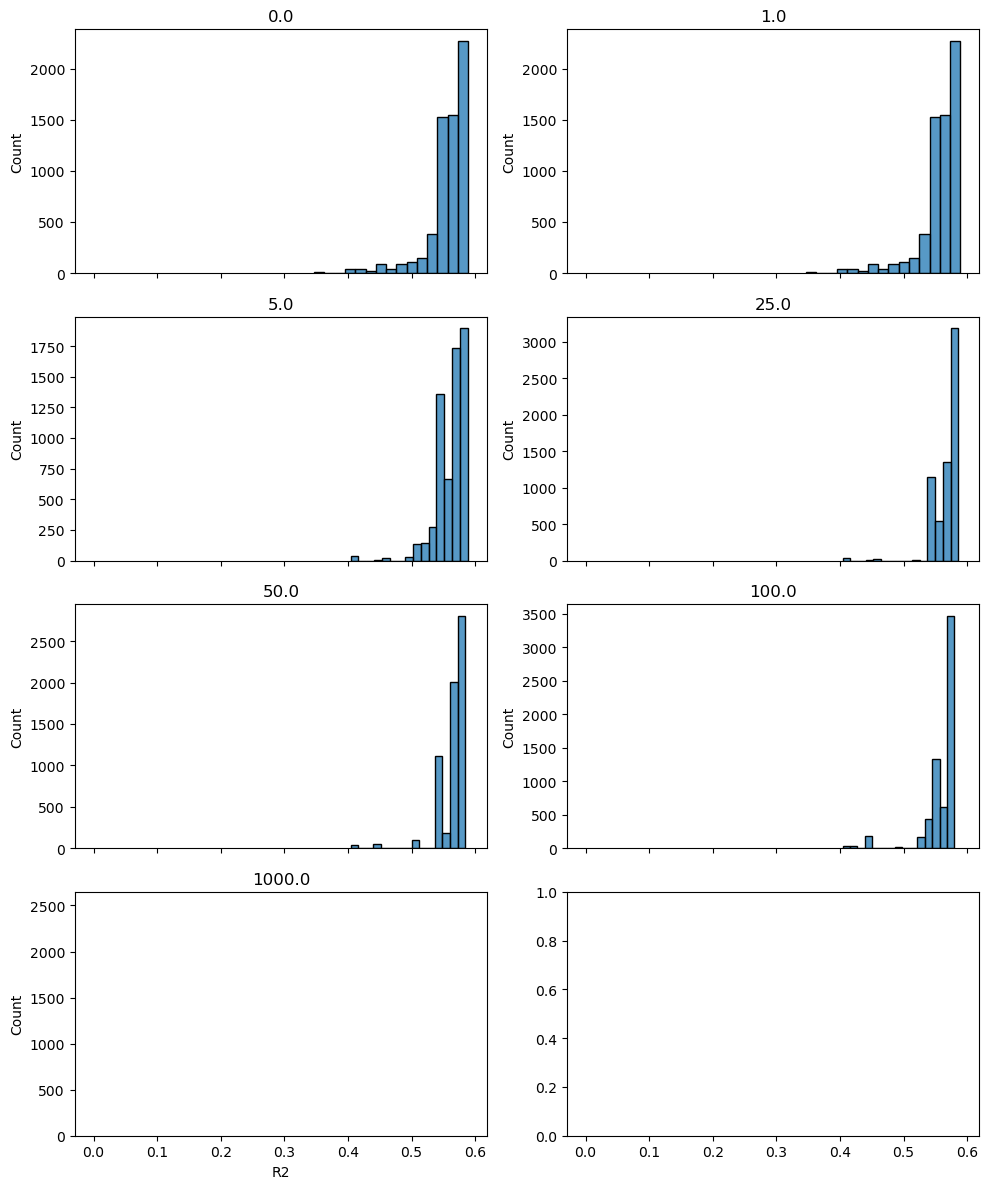

In [131]:
plot_histograms(round1_temp, 'min_child_weight', 15)

Good range for `min_child_weight`: $[0,5]$.

In [26]:
round1_temp.groupby('gamma')['val_r2_mean'].max()

gamma
0.0000      0.593290
0.0001      0.593290
0.0010      0.593290
0.0100      0.593291
1.0000      0.593368
10.0000     0.593093
100.0000    0.595106
Name: val_r2_mean, dtype: float64

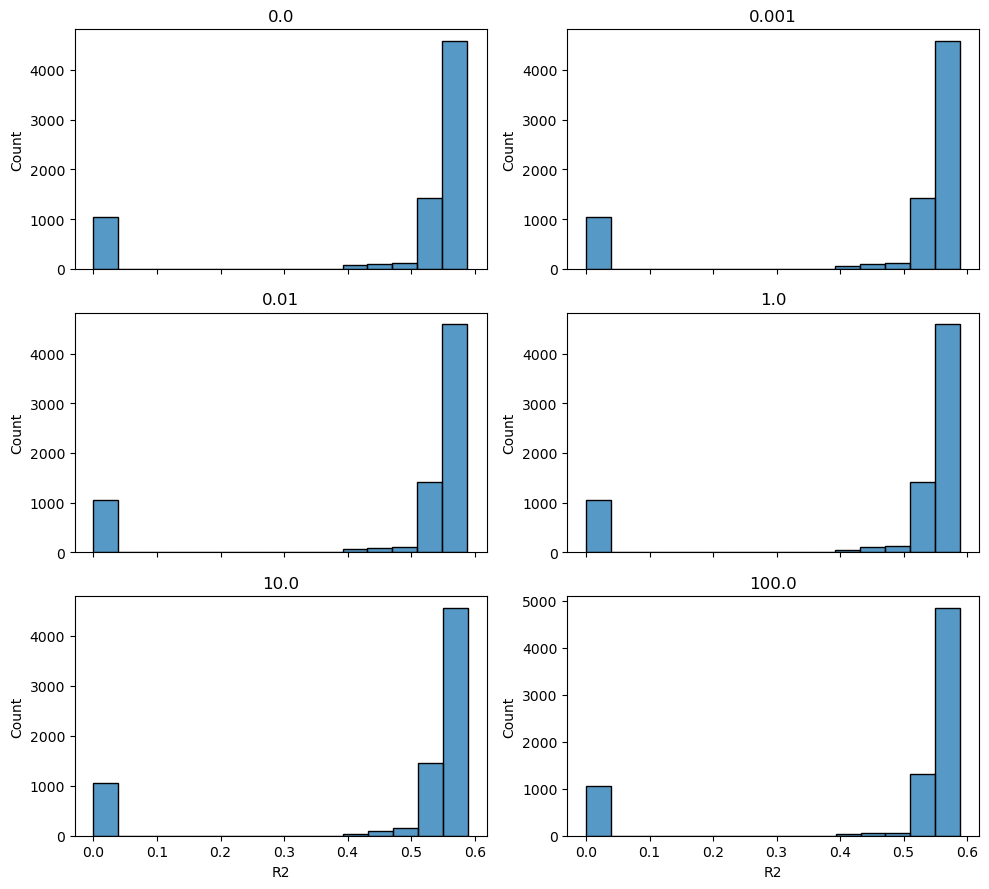

In [134]:
plot_histograms(round1_temp, 'gamma', 15)

Good range for `gamma`: $[1,500]$. Let's just get a little bit higher because it seems like the R2 keeps improving for higher gamma.

In [27]:
round1_temp.groupby('max_depth')['val_r2_mean'].max()

max_depth
1.0     0.559064
3.0     0.588833
5.0     0.595106
7.0     0.594357
10.0    0.592060
15.0    0.592951
Name: val_r2_mean, dtype: float64

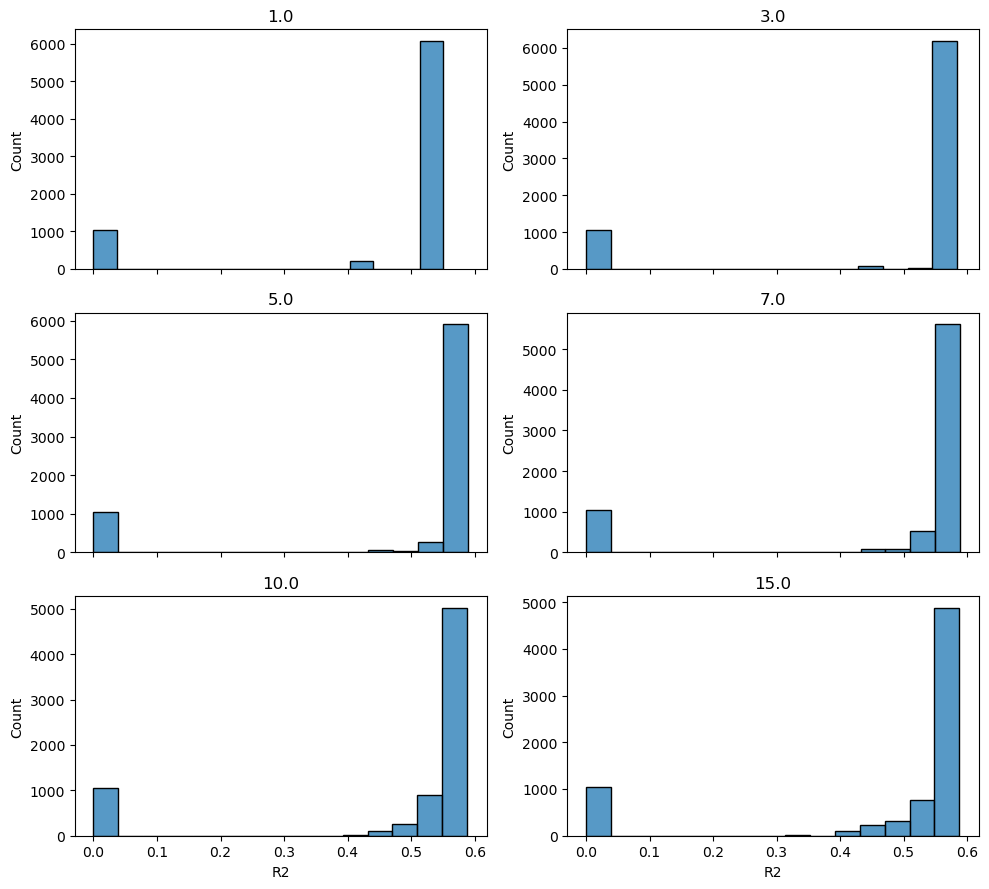

In [138]:
plot_histograms(round1_temp, 'max_depth', 15)

Best `max_depth` appear between $3$ and $10$

In [28]:
round1_temp.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000      0.594730
0.001      0.594578
0.010      0.595106
0.100      0.594870
1.000      0.594357
10.000     0.592510
100.000    0.585394
Name: val_r2_mean, dtype: float64

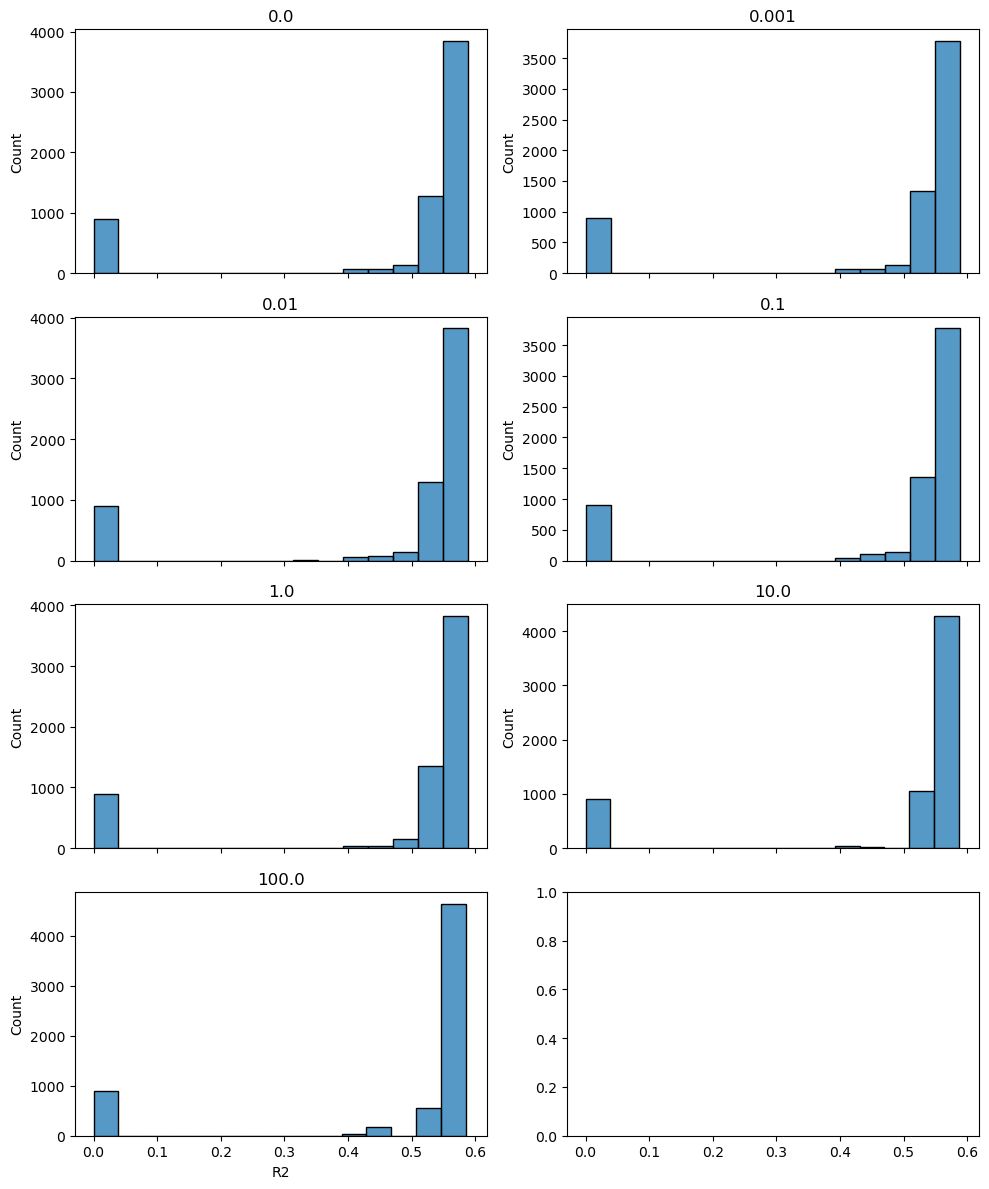

In [140]:
plot_histograms(round1_temp, 'reg_lambda', 15)

Best `reg_lambda` between $[0,1]$.

In [29]:
round1_temp.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.1    0.588520
0.3    0.595106
0.5    0.593964
0.7    0.593359
1.0    0.588700
Name: val_r2_mean, dtype: float64

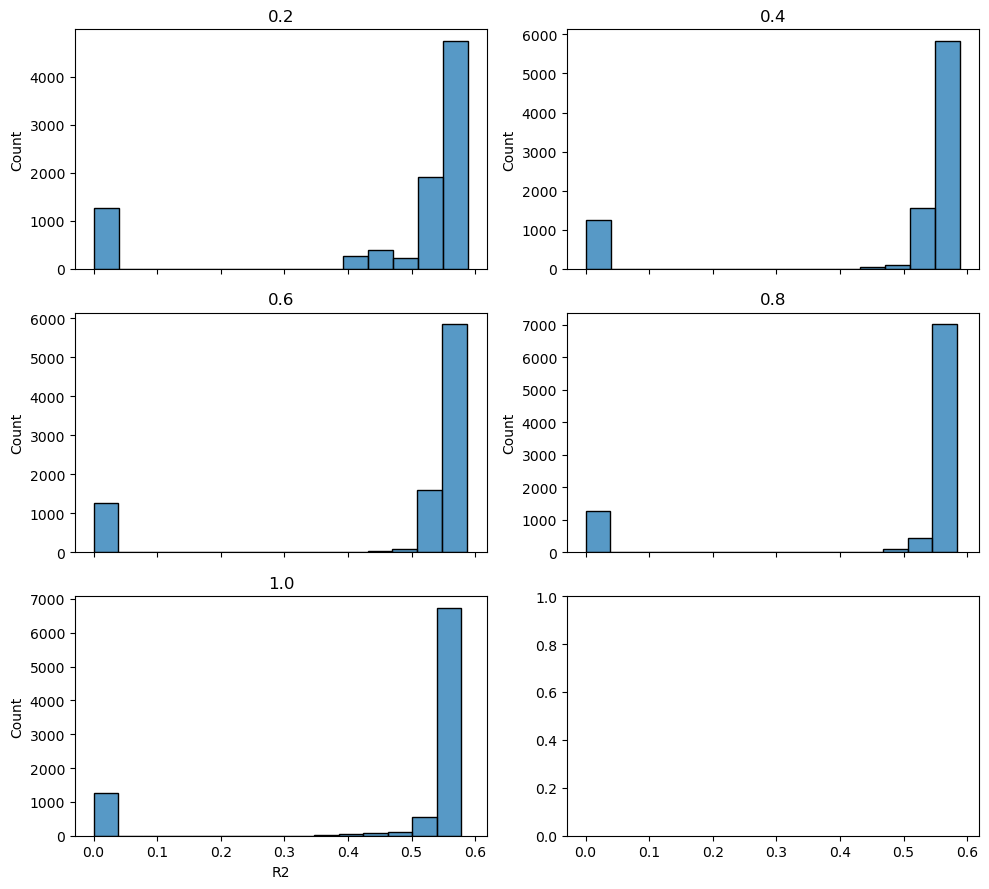

In [142]:
plot_histograms(round1_temp, 'subsample_frac', 15)

Range for `subsample_frac`: $[0.2, 0.8]$

In [30]:
round1_temp.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.592034
0.010    0.595106
0.050    0.592414
0.100    0.589560
0.300    0.586072
Name: val_r2_mean, dtype: float64

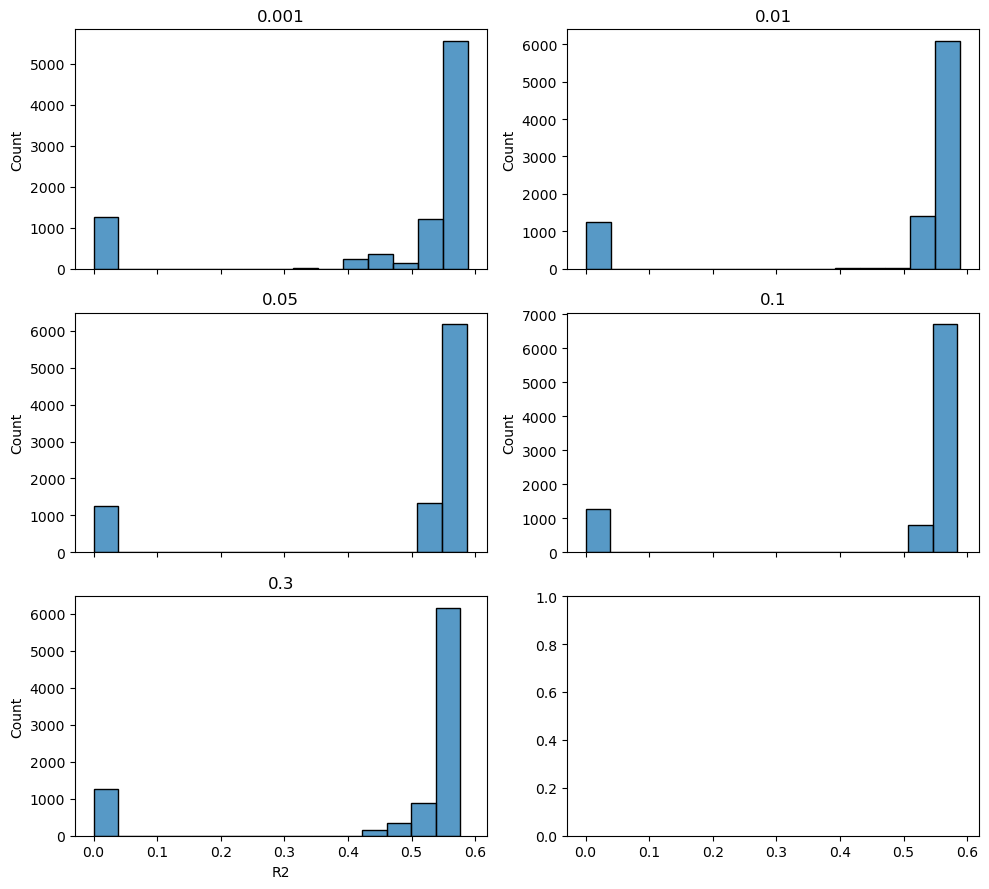

In [144]:
plot_histograms(round1_temp, 'eta', 15)

Good range for `eta`: $[0.001, 0.05]$.

Temp Round 1 Conclusions

+ `eta`: $[0.001, 0.05]$
+ `subsample_frac`: $[0.2, 0.8]$
+ `reg_lambda`: $[0,10]$ (but more evenly spaced than before)
+ `max_depth`: $[3, 10]$
+ `gamma`: $[1, 500]$
+ `min_child_weight`: $[0,25]$

### Round 2: Temp

In [36]:
with open('rounds/temp_round2_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [40]:
round2_temp = pd.read_csv('rounds/temp_xgb_round2.csv', index_col=False)

In [41]:
round2_temp.iloc[round2_temp.val_r2_mean.idxmax()]

Unnamed: 0                 15381.000000
gamma                         50.000000
max_depth                      5.000000
reg_lambda                     0.050000
min_child_weight               0.000000
subsample_frac                 0.300000
eta                            0.005000
num_boost                    947.000000
shrinkage_factor               1.009285
val_rmse_mean                  5.071612
val_r2_mean                    0.590225
test-r2-mean-ols-shrunk        0.513920
test-r2-mean-ols               0.513900
Name: 15381, dtype: float64

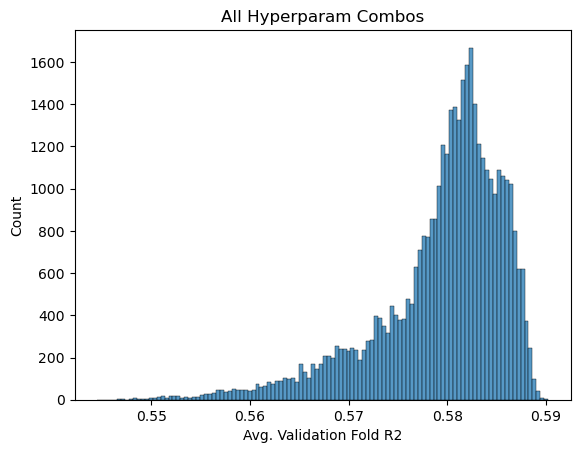

In [42]:
sns.histplot(data=round2_temp, x='val_r2_mean');
plt.title('All Hyperparam Combos')
plt.xlabel('Avg. Validation Fold R2');

In [43]:
round2_temp.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0    0.590225
1.0    0.590225
2.0    0.589873
3.0    0.589715
4.0    0.589183
5.0    0.588631
Name: val_r2_mean, dtype: float64

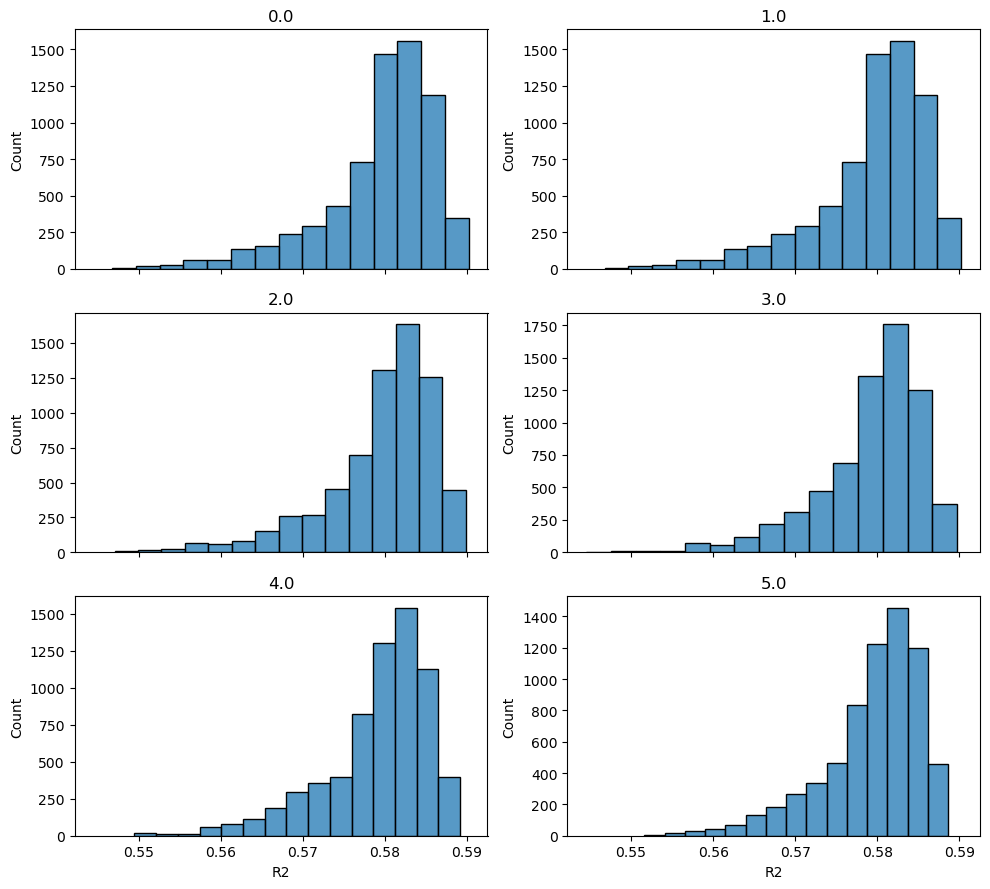

In [44]:
plot_histograms(round2_temp, 'min_child_weight', 15)

Good range for `min_child_weight`: $[0,2]$.

In [45]:
round2_temp.groupby('gamma')['val_r2_mean'].max()

gamma
1.0      0.589873
10.0     0.589841
50.0     0.590225
100.0    0.589468
150.0    0.589493
200.0    0.588879
Name: val_r2_mean, dtype: float64

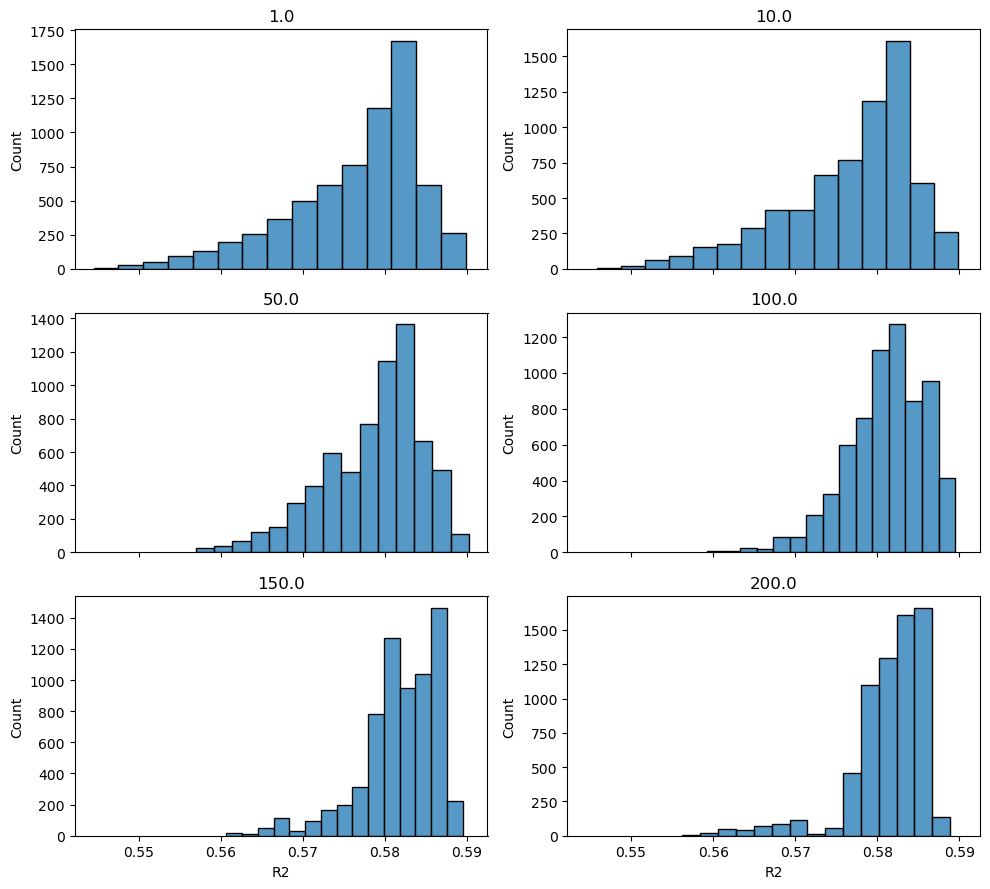

In [51]:
plot_histograms(round2_temp, 'gamma', 15)

Good range for `gamma`: $[10,100]$.

In [49]:
round2_temp.groupby('max_depth')['val_r2_mean'].max()

max_depth
3.0     0.585034
5.0     0.590225
7.0     0.589468
8.0     0.589335
10.0    0.589493
Name: val_r2_mean, dtype: float64

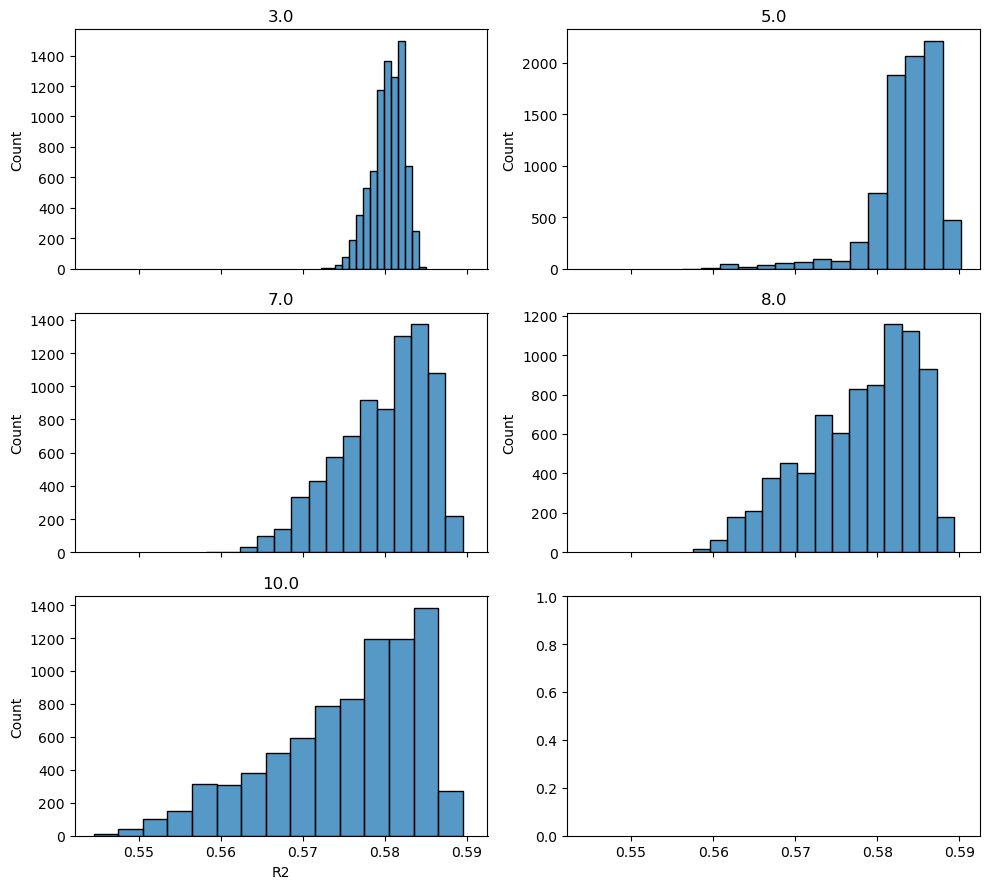

In [50]:
plot_histograms(round2_temp, 'max_depth', 15)

Best `max_depth` appear between $3$ and $7$

In [52]:
round2_temp.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000    0.589329
0.001    0.589215
0.005    0.589468
0.010    0.589158
0.050    0.590225
0.100    0.589873
0.500    0.589715
1.000    0.589171
Name: val_r2_mean, dtype: float64

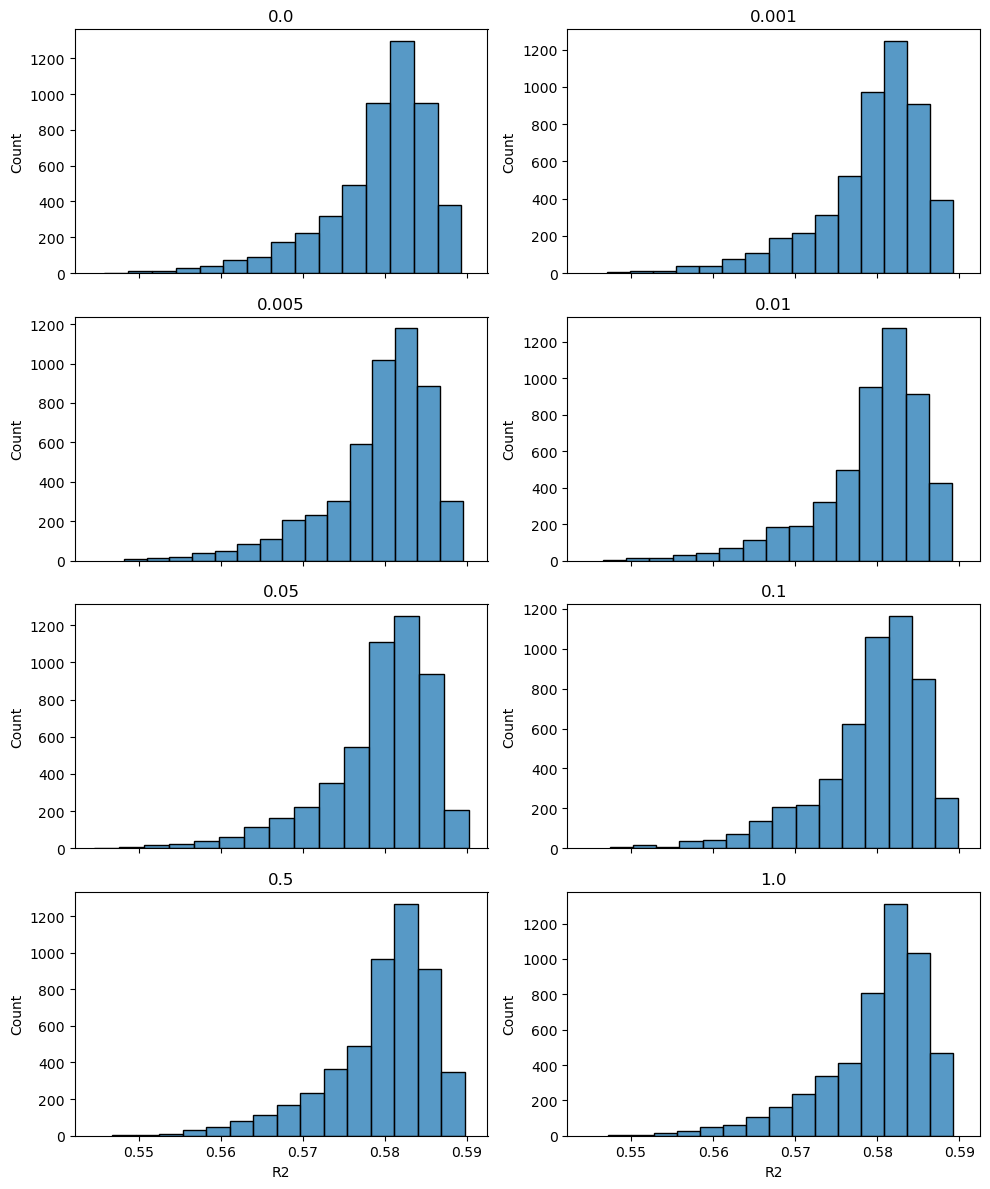

In [53]:
plot_histograms(round2_temp, 'reg_lambda', 15)

Best `reg_lambda` between $[0.01,0.1]$.

In [54]:
round2_temp.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.2    0.589873
0.3    0.590225
0.4    0.589171
0.5    0.589493
0.6    0.586855
0.7    0.586452
0.8    0.584280
Name: val_r2_mean, dtype: float64

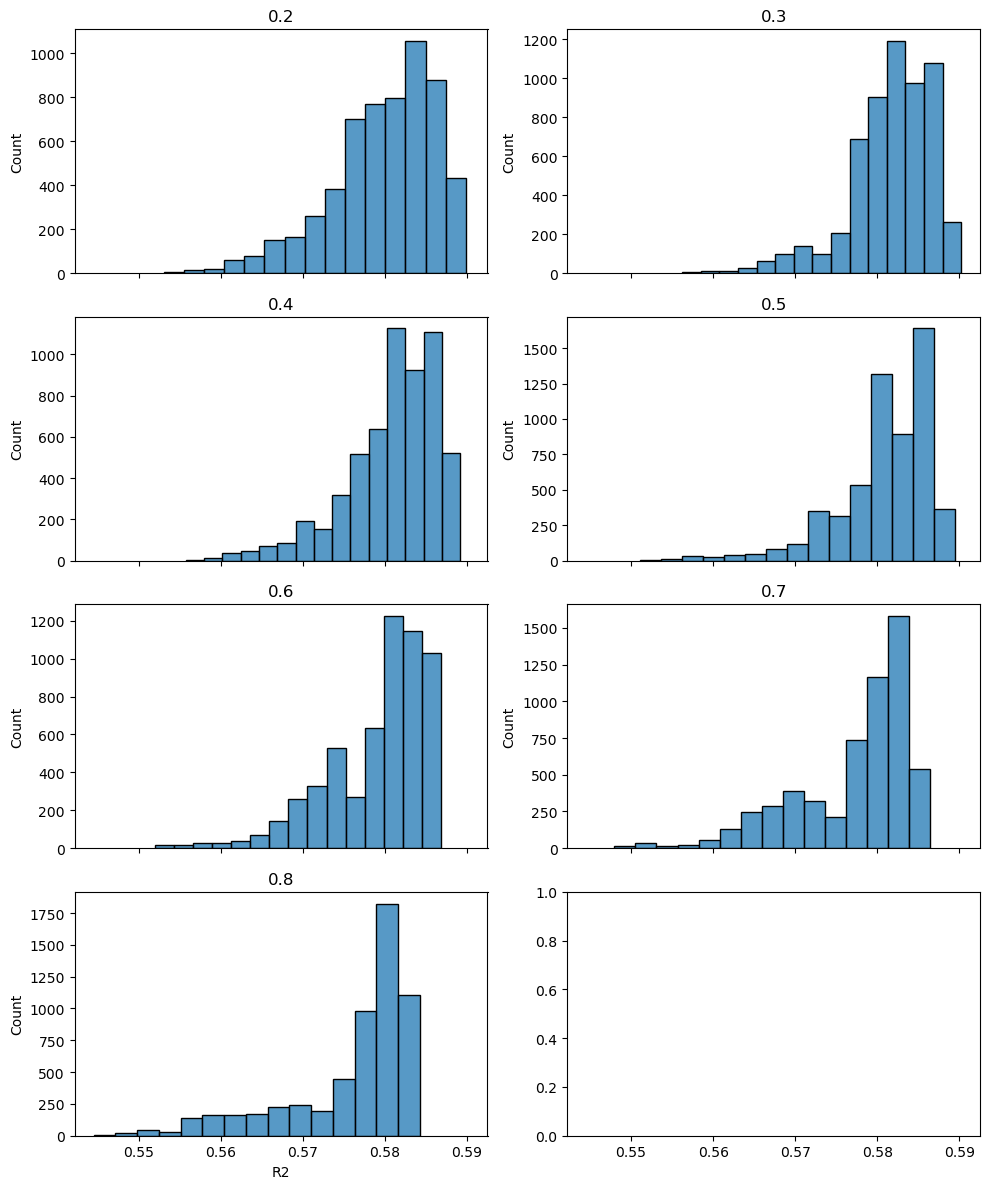

In [55]:
plot_histograms(round2_temp, 'subsample_frac', 15)

Range for `subsample_frac`: $[0.2, 0.5]$

In [56]:
round2_temp.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.589522
0.005    0.590225
0.010    0.589873
0.050    0.588879
Name: val_r2_mean, dtype: float64

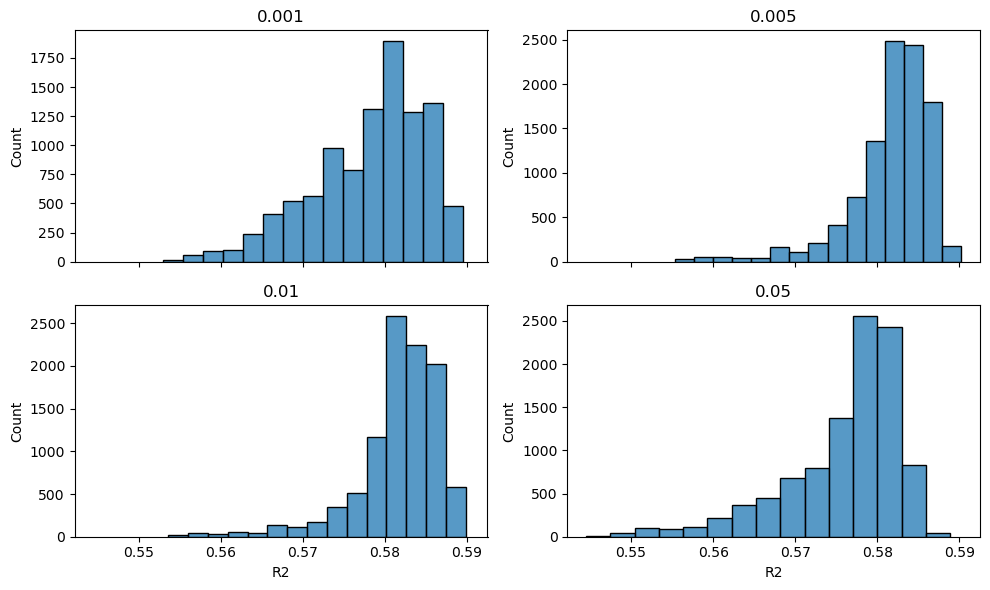

In [57]:
plot_histograms(round2_temp, 'eta', 15)

Good range for `eta`: $[0.001, 0.005, 0.01]$.

Temp Round 2 Conclusions

+ `eta`: $[0.001, 0.005, 0.05]$
+ `subsample_frac`: $[0.2, 0.5]$
+ `reg_lambda`: $[0.01,0.1]$ (but more evenly spaced than before)
+ `max_depth`: $[3, 7]$
+ `gamma`: $[10, 100]$
+ `min_child_weight`: $[0,2]$

### Round 3: Temp

In [10]:
round3_temp = pd.read_csv('rounds/temp_xgb_round3.csv', index_col=False)

In [11]:
best_performer = round3_temp.iloc[round3_snow['val_r2_mean'].idxmax()]
best_performer = best_performer[['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'subsample_frac', 'eta', 'num_boost', 'shrinkage_factor']]

In [12]:
with open("best_temp_xgb.json", "w") as json_file:
    json.dump(best_performer.to_dict(), json_file, indent=4)

## Extreme

### GRF

#### Round 1: Snow

In [2]:
snow_res = pd.read_csv('rounds_intermediate/snow_grf_round1.csv')

In [8]:
best_snow = snow_res.iloc[snow_res.mean_cv_loss.idxmin()]
best_snow

num_trees        1000.000000
min_node_size      10.000000
sample_frac         0.800000
alpha               0.250000
mean_cv_loss        0.050264
Name: 3655, dtype: float64

In [10]:
with open("best_snow_grf.json", "w") as json_file:
    json.dump(best_snow.to_dict(), json_file, indent=4)

#### Round 1: Temp

In [11]:
temp_res = pd.read_csv('rounds_intermediate/temp_grf_round1.csv')

In [13]:
best_temp = temp_res.iloc[snow_res.mean_cv_loss.idxmin()]
best_temp

num_trees        1000.000000
min_node_size      10.000000
sample_frac         0.800000
alpha               0.250000
mean_cv_loss        1.497621
Name: 3655, dtype: float64

In [14]:
with open("best_temp_grf.json", "w") as json_file:
    json.dump(best_temp.to_dict(), json_file, indent=4)

### gbex

#### Round 1: Snow

In [12]:
snow_res = pd.read_csv('rounds_extreme/snow_gbex_round1.csv')
temp_res = pd.read_csv('rounds_extreme/temp_gbex_round1.csv')

In [25]:
best_snow = snow_res.iloc[snow_res['mean_cv_loss'].idxmin()]
best_snow

depth_sigma         1.000000
depth_gamma         2.000000
lambda_scale        0.050000
lambda_ratio        1.000000
min_leaf_sigma     10.000000
min_leaf_gamma     10.000000
sf                  0.600000
mean_cv_loss       -2.124628
num_trees         113.000000
Name: 6047154, dtype: float64

In [26]:
with open("best_snow_gbex.json", "w") as json_file:
    json.dump(best_snow.to_dict(), json_file, indent=4)

#### Round 1: Temp

In [27]:
best_temp = temp_res.iloc[temp_res['mean_cv_loss'].idxmin()]
best_temp

depth_sigma        2.000000
depth_gamma        0.000000
lambda_scale       0.100000
lambda_ratio       1.000000
min_leaf_sigma     7.000000
min_leaf_gamma    10.000000
sf                 0.400000
mean_cv_loss       1.669121
num_trees          3.000000
Name: 2756757, dtype: float64

In [28]:
with open("best_temp_gbex.json", "w") as json_file:
    json.dump(best_temp.to_dict(), json_file, indent=4)